# Download & Unpack ZIP

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_id = "15kxsv3BiN-9iQrpyzobKNl_oFhWWOwDr"
zip_path = "/content/drive/MyDrive/potsdam/Potsdam-GeoTif.zip"
extract_path = "/content/potsdam"

import os
#Create folder in drive if it does not exist
os.makedirs(os.path.dirname(zip_path), exist_ok=True)

#Download only if not already in drive
if not os.path.exists(zip_path):
    !gdown --id $file_id -O $zip_path
else:
    print("Dataset already exists in Drive")

expectedFile = os.path.join(extract_path, "Potsdam-GeoTif")
#Unpack only if not already unpacked
if not os.path.exists(expectedFile):
    os.makedirs(extract_path, exist_ok=True)
    !unzip -q $zip_path -d $extract_path
else:
    print("ZIP already unpacked")

print("Download & Unpack complete")

Dataset already exists in Drive
Download & Unpack complete


# Step 1 / Dataset preparation






In [ ]:
import glob

tifs = glob.glob("/content/potsdam/**/*.tif", recursive=True)

#Just sanity check
print("Number of files:", len(tifs))

Number of files: 15048


In [ ]:
import random
import numpy as np
random.seed(42)

nSamples = 5000

allFiles = tifs.copy()

sampledFiles = random.sample(allFiles, nSamples)
#Sanity check
print("Sampled files:", len(sampledFiles))

Sampled files: 5000


In [ ]:
def createFolds(fileList, nFolds=5):
    random.shuffle(fileList)
    folds = np.array_split(fileList, nFolds)
    return folds

#Sanity check
folds = createFolds(sampledFiles, nFolds=5)
for i in range(len(folds)):
    fold = folds[i]
    print(f"Fold {i+1}: {len(fold)} files")

Fold 1: 1000 files
Fold 2: 1000 files
Fold 3: 1000 files
Fold 4: 1000 files
Fold 5: 1000 files


In [ ]:
trainFiles = list(folds[0]) + list(folds[1]) + list(folds[2])
valFiles   = list(folds[3])
testFiles  = list(folds[4])

#Sanity check
print("Train:", len(trainFiles))
print("Val:", len(valFiles))
print("Test:", len(testFiles))

Train: 3000
Val: 1000
Test: 1000


In [ ]:
#Trying to create tfrecord for each fold
#Serializer
import tensorflow as tf
imgSize = 224
nBands = 5

def serializeTFR(image, label):

    image = image.astype(np.float32)
    label = label.astype(np.uint8)

    feature = {
        "image": tf.train.Feature(
            bytes_list=tf.train.BytesList(
                value=[image.tobytes()]
            )
        ),
            "label": tf.train.Feature(
            bytes_list=tf.train.BytesList(
                value=[label.tobytes()]
            )
        ),
    }
    example = tf.train.Example(
        features = tf.train.Features(feature=feature)
    )
    return example.SerializeToString()

#Writer

def writeTFRecord(tilePaths, tfrecordPath):

    with tf.io.TFRecordWriter(tfrecordPath) as writer:
        for blob in tilePaths:


            with rio.open(blob) as img:
                imgArray = img.read().transpose(1, 2, 0).astype(np.float32)

            #We only normalize rgb here
            #I think its easier to apply ir and elevation in the training pipeline
            #imgArray[:, :, 0:3] /= 255.0


            image = imgArray[:, :, 0:5]
            label = imgArray[:, :, 5].astype(np.uint8)

            example = serializeTFR(image, label)
            writer.write(example)

    print("Finished writing:", tfrecordPath)

In [ ]:
#Create TFRecords for each fold

tfRecordOutputDir = "/content/drive/MyDrive/potsdam/tfrecords"

os.makedirs(tfRecordOutputDir, exist_ok=True)

allExist = all(
    os.path.exists(os.path.join(tfRecordOutputDir, f"fold_{i}.tfrecord"))
    for i in range(5)
)

if not allExist:
    print("TFRecords not found, creating one for each fold.")

    for i, fold in enumerate(folds):
        tfrecordPath = os.path.join(tfRecordOutputDir, f"fold_{i}.tfrecord")
        writeTFRecord(fold, tfrecordPath)
else:
    print("TFRecords already exist, skipping creation.")


TFRecords already exist, skipping creation.


In [ ]:
import rasterio as rio
import matplotlib.pyplot as plt


PathToGeoTiffFile = "/content/potsdam/Potsdam-GeoTif"
print("Path set to:", PathToGeoTiffFile)

Path set to: /content/potsdam/Potsdam-GeoTif


In [ ]:
allTiles = glob.glob(PathToGeoTiffFile + "/*.tif")

for tile in allTiles:
    if "0000000224-0000042784.tif" not in tile:
        blob = tile
        break

print("Using:", blob)

Using: /content/potsdam/Potsdam-GeoTif/0000031136-0000031584.tif


In [ ]:
import rasterio as rio
img = rio.open(blob)
imgArray = img.read().transpose(1, 2, 0)

print("Shape:", imgArray.shape)

Shape: (224, 224, 6)


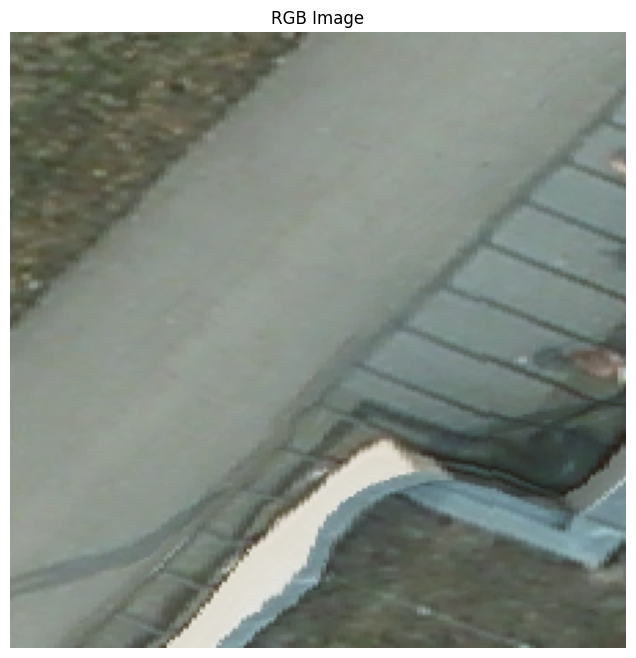

In [ ]:
#Visualize RGB
plt.figure(figsize=(24,8))
plt.imshow(imgArray[:,:,0:3] / 255.0)
plt.title("RGB Image")
plt.axis("off")
plt.show()

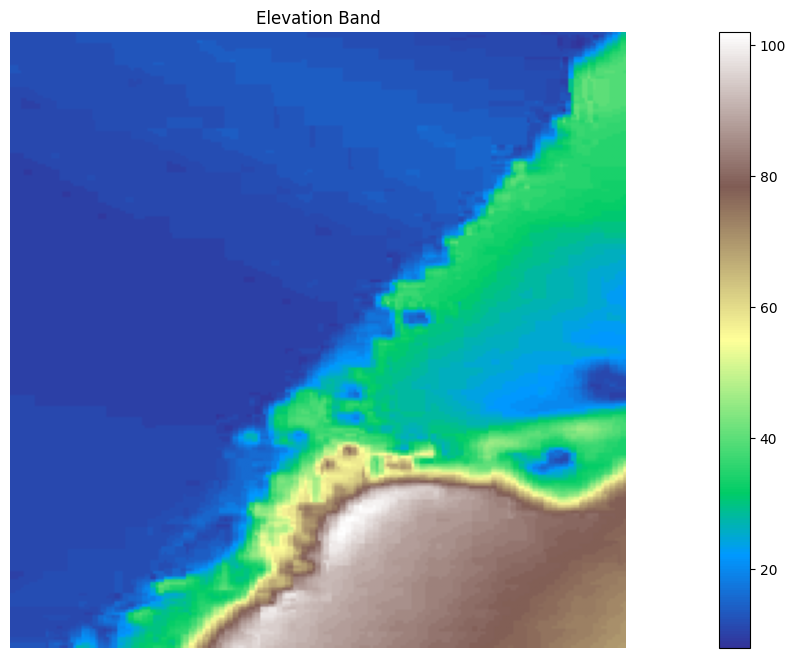

[[12. 12. 12. ... 23. 28. 28.]
 [12. 12. 12. ... 26. 30. 30.]
 [12. 12. 12. ... 28. 32. 32.]
 ...
 [12. 12. 12. ... 70. 70. 70.]
 [13. 13. 13. ... 70. 69. 69.]
 [13. 13. 13. ... 69. 69. 69.]]


In [ ]:
#Visualize Elevation Band
plt.figure(figsize=(24,8))
#It is not explicitly specified that it is 4,
#but in the ordering mentioned in canvas it is in 4th place.
plt.imshow(imgArray[:,:,4], cmap="terrain")
plt.title("Elevation Band")
plt.colorbar()
plt.axis("off")
plt.show()
print(imgArray[:,:,4])

In [ ]:
#Checking target band classes

labelBand = imgArray[:, :, 5].astype(np.int32)

print("Unique label values:", np.unique(labelBand))

Unique label values: [0 1 2]


In [ ]:
classNames = [
    "Impervious surface",   # 0
    "Building",             # 1
    "Tree",                 # 2
    "Low vegetation",       # 3
    "Car",                  # 4
    "Clutter/Background"    # 5
]

import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap([
    "red",          # 0
    "yellow",       # 1
    "lightblue",    # 2
    "green",        # 3
    "orange",       # 4
    "gray"          # 5
])

colors = ([
    "red",          # 0
    "yellow",       # 1
    "lightblue",    # 2
    "green",        # 3
    "orange",       # 4
    "gray"          # 5
])

print("Colormap set")

Colormap set


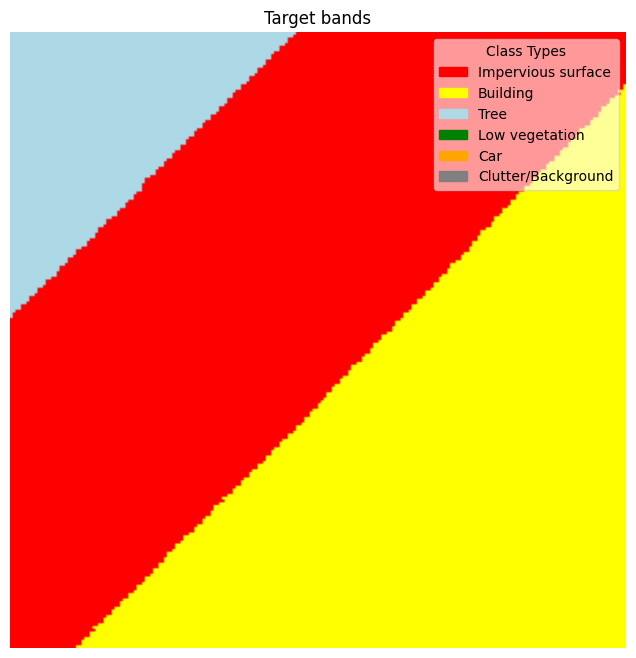

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.figure(figsize=(24,8))

plt.imshow(labelBand, cmap=cmap, vmin=0, vmax=5)
plt.title("Target bands")
plt.axis("off")

patches = [mpatches.Patch(color=colors[i], label=classNames[i])for i in range(6)]

plt.legend(handles=patches, title="Class Types", loc="upper right", framealpha=0.6)



# Trying to parse the TFRecords to be usable in training xd


In [ ]:
imgSize = 224
nBands = 5

def parseTFRecord(tfrecordFile):

    featureDescription = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.string),
    }

    parsed = tf.io.parse_single_example(tfrecordFile,
                                        featureDescription)

    image = tf.io.decode_raw(parsed["image"], tf.float32)
    label = tf.io.decode_raw(parsed["label"], tf.uint8)

    image = tf.reshape(image, [imgSize, imgSize, nBands])
    label = tf.reshape(label, [imgSize, imgSize])

    return image, label

In [ ]:

#We dont parse here, because we need to shuffle before parsing.
def loadFold(foldId, tfRecordDir):
    path = f"{tfRecordDir}/fold_{foldId}.tfrecord"
    return tf.data.TFRecordDataset(path)

### Preprocess sets

In [ ]:
# Load folds
tfRecordDir = "/content/drive/MyDrive/potsdam/tfrecords"

train_raw = (
    loadFold(0, tfRecordDir)
    .concatenate(loadFold(1, tfRecordDir))
    .concatenate(loadFold(2, tfRecordDir))
)

val_raw = loadFold(3, tfRecordDir)
test_raw = loadFold(4, tfRecordDir)

In [ ]:
# Get mean and standard deviation for each band

#Had to add this to calculate the mean/std, because we need to
#shuffle before parsing the actual training set, RAM crashes otherwise :/
statsDataset = (
    train_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
)

sum_channels = np.zeros(nBands)
sum_sq_channels = np.zeros(nBands)
n_pixels_total = 0

# Only compute in training set
for image, _ in statsDataset:
    img = image.numpy()

    sum_channels += img.sum(axis=(0,1))
    sum_sq_channels += (img**2).sum(axis=(0,1))

    n_pixels_total += img.shape[0] * img.shape[1]

mean = sum_channels / n_pixels_total

std = np.sqrt(
    (sum_sq_channels / n_pixels_total) - (mean ** 2)
)

print("Mean:", mean)
print("Std:", std)

Mean: [ 0.33438664  0.35870846  0.33283279 97.03641039 44.77261812]
Std: [ 0.138674    0.13667672  0.14290086 35.64669464 54.29818486]


In [ ]:
def augment(image, label):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        label = tf.image.flip_left_right(label[..., tf.newaxis])[..., 0]

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        label = tf.image.flip_up_down(label[..., tf.newaxis])[..., 0]

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    label = tf.image.rot90(label[..., tf.newaxis], k)[..., 0]

    return image, label

In [ ]:
# TF needs tensors xd in pipeline
mean_tf = tf.constant(mean, dtype=tf.float32)
std_tf = tf.constant(std, dtype=tf.float32)

# Aux func for preprocess image
def preprocess(image, label):
    image = (image - mean_tf) / std_tf
    return image, label

#These are used for step 2, because we have to slice out elevation
mean_tf2 = tf.constant(mean[:4], dtype=tf.float32)
std_tf2  = tf.constant(std[:4], dtype=tf.float32)


#Need to slice it for step2.
def preprocessStep2(image, label):
    image = image[..., :4]
    image = (image - mean_tf2) / std_tf2
    label = tf.one_hot(label, depth=6)
    return image, label

# Maybe not necessary the shuffle. It considers a 1000 size window to shuffle
# Batch is for instead of updating the network in each image, it will update every 8 images
# Prefetch allows cpu preparing next batch while gpu training current
train_dataset = (
    train_raw
    .shuffle(1000)
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
# Just checking standardization

for image, label in train_dataset.take(1):
    print(image[0])

tf.Tensor(
[[[-0.799409   -0.9029655  -0.9021025   1.4857925 ]
  [-0.5166184  -0.58735013 -0.5727914   1.8504827 ]
  [-0.4600603  -0.5299655  -0.43557847  1.8785359 ]
  ...
  [-0.68629277 -0.7308116  -0.8746599   1.2052616 ]
  [-0.71457183 -0.7595039  -0.8746599   1.317474  ]
  [-0.7428509  -0.7308116  -0.8472173   1.4296863 ]]

 [[-0.799409   -0.9029655  -0.9021025   1.4857925 ]
  [-0.5166184  -0.58735013 -0.5727914   1.8504827 ]
  [-0.4600603  -0.5299655  -0.43557847  1.8785359 ]
  ...
  [-0.68629277 -0.7308116  -0.8746599   1.2052616 ]
  [-0.71457183 -0.7595039  -0.8746599   1.317474  ]
  [-0.7428509  -0.7308116  -0.8472173   1.4296863 ]]

 [[-0.71457183 -0.8168886  -0.7923321   1.7943766 ]
  [-0.6297347  -0.7308116  -0.6825618   1.7943766 ]
  [-0.5731765  -0.673427   -0.54534876  1.7943766 ]
  ...
  [-0.8842461  -0.98904234 -1.0667579   0.9247307 ]
  [-0.799409   -0.9029655  -0.9021025   1.2052616 ]
  [-0.4600603  -0.5299655  -0.4904636   1.7663234 ]]

 ...

 [[-0.4035022  -0.55865

# Step 2 / Training a simple model

In [ ]:
import tensorflow as tf

imgSize = 224
nClasses = 6

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(imgSize, imgSize, 4)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.Conv2D(
        filters=nClasses,
        kernel_size=(3,3),
        padding="same",
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 6)    │         1,734 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,918 (11.40 KB)

 Trainable params: 2,918 (11.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20
    375/Unknown 24s 46ms/step - accuracy: 0.4288 - loss: 1.3535

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 1.11947, saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - accuracy: 0.4290 - loss: 1.3532 - val_accuracy: 0.5505 - val_loss: 1.1195
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5695 - loss: 1.0738
Epoch 2: val_loss improved from 1.11947 to 1.05242, saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5695 - loss: 1.0738 - val_accuracy: 0.5782 - val_loss: 1.0524
Epoch 3/20
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5949 - loss: 1.0220
Epoch 3: val_loss improved from 1.05242 to 1.02619, saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.5949 - loss: 1.0220 - val_accuracy: 0.5904 - val_loss: 1.0262
Epoch 4/20
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5971 - loss: 1.0196
Epoch 4: val_loss did not improve from 1.02619
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.5971 - loss: 1.0196 - val

In [ ]:
best_model = tf.keras.models.load_model("best_model.keras")

test_loss, test_acc = best_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 170ms/step - accuracy: 0.6190 - loss: 0.9500
Test Loss: 0.9238972067832947
Test Accuracy: 0.6339982748031616


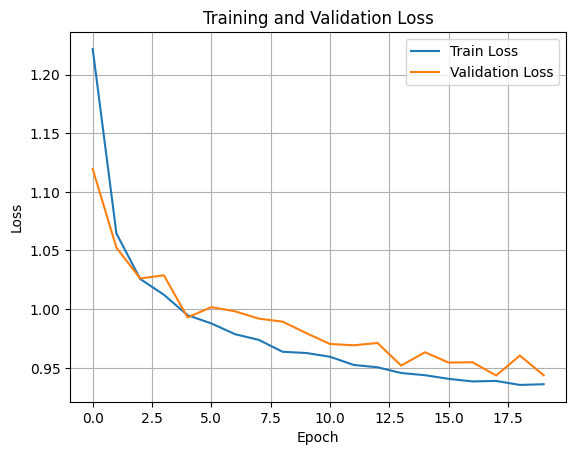

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

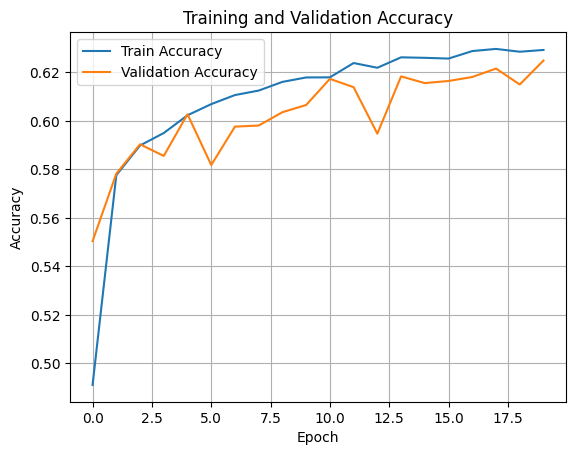

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()